### **Convolutinal Neural Network (CNN)**

In [ ]:
import torch
import torch.nn as nn

In [39]:
### Simple Convolution layer example.
class SimpleConvLayer(nn.Module):
    def __init__(self, in_channel, output_channel, kernel_size=3, stride=1, padding=1):
        super(SimpleConvLayer, self).__init__()
        self.conv = nn.Conv2d(in_channel, output_channel, kernel_size=kernel_size, stride=stride, padding=padding)
        self.pooling = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        # self.pooling = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
    
    def forward(self, x):
        x = self.conv(x)
        x = self.pooling(x)
        return x
    
## Number of Parameters in Conv Layer
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [40]:
## Example usage

conv_layer = SimpleConvLayer(in_channel=3, output_channel=64, kernel_size=3, stride=1, padding=1)

input_tensor = torch.randn(1, 3, 64, 64)  # Batch size of 1, 3 channels, 64x64 image
output_tensor = conv_layer(input_tensor)
print(f"Input shape: {input_tensor.shape}")
print(f"Tensor shape after Conv Layer: {output_tensor.shape}")
num_params = count_parameters(conv_layer)
print(f"Number of parameters in Conv Layer: {num_params}")

Input shape: torch.Size([1, 3, 64, 64])
Tensor shape after Conv Layer: torch.Size([1, 64, 32, 32])
Number of parameters in Conv Layer: 1792


In [41]:
## Example usage

conv_layer = SimpleConvLayer(in_channel=3, output_channel=64, kernel_size=5, stride=1, padding=2)

input_tensor = torch.randn(1, 3, 64, 64)  # Batch size of 1, 3 channels, 64x64 image
output_tensor = conv_layer(input_tensor)
print(f"Input shape: {input_tensor.shape}")
print(f"Tensor shape after Conv Layer: {output_tensor.shape}")
num_params = count_parameters(conv_layer)
print(f"Number of parameters in Conv Layer: {num_params}")


Input shape: torch.Size([1, 3, 64, 64])
Tensor shape after Conv Layer: torch.Size([1, 64, 32, 32])
Number of parameters in Conv Layer: 4864


In [42]:
## Example usage

conv_layer = SimpleConvLayer(in_channel=3, output_channel=64, kernel_size=7, stride=1, padding=3)

input_tensor = torch.randn(1, 3, 64, 64)  # Batch size of 1, 3 channels, 64x64 image
output_tensor = conv_layer(input_tensor)
print(f"Input shape: {input_tensor.shape}")
print(f"Tensor shape after Conv Layer: {output_tensor.shape}")
num_params = count_parameters(conv_layer)
print(f"Number of parameters in Conv Layer: {num_params}")


Input shape: torch.Size([1, 3, 64, 64])
Tensor shape after Conv Layer: torch.Size([1, 64, 32, 32])
Number of parameters in Conv Layer: 9472


In [43]:
class DoubleConvLayer(nn.Module):
    def __init__(self, in_channel, output_channel, kernel_size=3, stride=1, padding=1):
        super(DoubleConvLayer, self).__init__()
        self.conv1 = nn.Conv2d(in_channel, in_channel, kernel_size=kernel_size, stride=stride, padding=padding)
        self.conv2 = nn.Conv2d(in_channel, output_channel, kernel_size=kernel_size, stride=stride, padding=padding)
        self.pooling = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        # self.pooling = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pooling(x)
        return x

In [45]:
## Example usage

conv_layer = DoubleConvLayer(in_channel=4, output_channel=100, kernel_size=3, stride=1, padding=1)

input_tensor = torch.randn(1, 4, 64, 64)  # Batch size of 1, 3 channels, 64x64 image
output_tensor = conv_layer(input_tensor)
print(f"Input shape: {input_tensor.shape}")
print(f"Tensor shape after Conv Layer: {output_tensor.shape}")
num_params = count_parameters(conv_layer)
print(f"Number of parameters in Conv Layer: {num_params}")


Input shape: torch.Size([1, 4, 64, 64])
Tensor shape after Conv Layer: torch.Size([1, 100, 32, 32])
Number of parameters in Conv Layer: 3848


In [46]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

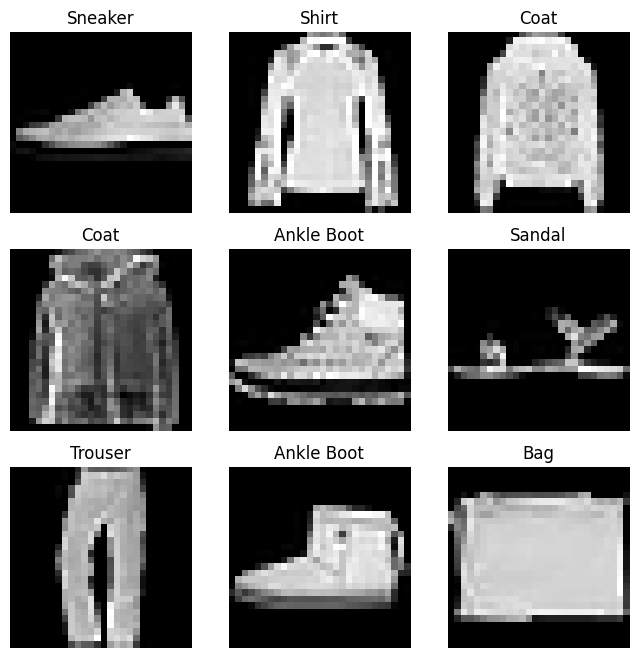

In [48]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [49]:
training_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [50]:
training_data[0][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [51]:
training_data[0][0].shape

torch.Size([1, 28, 28])

In [52]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

In [53]:
sample_input, sample_label = next(iter(train_dataloader))
print(f"Shape of input tensor: {sample_input.shape}")
print(f"Shape of label tensor: {sample_label.shape}")

Shape of input tensor: torch.Size([64, 1, 28, 28])
Shape of label tensor: torch.Size([64])


In [54]:
### LeNet-5 Architecture
class LeNet5(nn.Module):
    def __init__(self, in_channel, num_classes):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(in_channel, 6, kernel_size=5, stride=1, padding=0)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(-1, 16 * 4 * 4)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [55]:
model_LeNet5 = LeNet5(in_channel=1, num_classes=10)
print(model_LeNet5)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu): ReLU()
)


In [56]:
num_params_LeNet = count_parameters(model_LeNet5)
print(f"Number of parameters in LeNet-5: {num_params_LeNet}")

Number of parameters in LeNet-5: 44426


In [57]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [58]:
### Training Loop of LeNet5 model
import time
model_LeNet5.to(device)

start_time = time.time()
epochs = 10
loss_history = []
val_history = []
criterian = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_LeNet5.parameters(), lr=0.01, momentum=0.9)


for epoch in range(epochs):
    model_LeNet5.train()
    running_loss = 0.0
    acc_train = 0.0
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_LeNet5(inputs)
        loss = criterian(outputs, labels)
        _, predicted_ = torch.max(outputs.data, 1)
        acc_train += (predicted_ == labels).sum().item()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    else:
        val_loss = 0.0
        accuracy = 0.0
        model_LeNet5.eval()
        with torch.no_grad():
            for val_inputs, val_labels in test_dataloader:
                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                val_outputs = model_LeNet5(val_inputs)
                val_loss += criterian(val_outputs, val_labels).item()
                _, predicted = torch.max(val_outputs.data, 1)
                accuracy += (predicted == val_labels).sum().item()
        loss_history.append(running_loss/len(train_dataloader))
        val_history.append(val_loss/len(test_dataloader))
        print(f"Epoch: {epoch+1} | Train Loss: {running_loss/len(train_dataloader):.4f} | Training Accuracy: {acc_train/len(training_data):.4f}| Val Loss: {val_loss/len(test_dataloader):.4f} | Val Accuracy: {accuracy/len(test_data):.4f}")
        end_time = time.time()
print(f"Training time: {end_time - start_time} seconds")

Epoch: 1 | Train Loss: 0.9449 | Training Accuracy: 0.6415| Val Loss: 0.5930 | Val Accuracy: 0.7778
Epoch: 2 | Train Loss: 0.5335 | Training Accuracy: 0.8002| Val Loss: 0.5313 | Val Accuracy: 0.7996
Epoch: 3 | Train Loss: 0.4619 | Training Accuracy: 0.8270| Val Loss: 0.4415 | Val Accuracy: 0.8397
Epoch: 4 | Train Loss: 0.4186 | Training Accuracy: 0.8452| Val Loss: 0.4254 | Val Accuracy: 0.8423
Epoch: 5 | Train Loss: 0.3833 | Training Accuracy: 0.8577| Val Loss: 0.4004 | Val Accuracy: 0.8529
Epoch: 6 | Train Loss: 0.3640 | Training Accuracy: 0.8644| Val Loss: 0.4089 | Val Accuracy: 0.8523
Epoch: 7 | Train Loss: 0.3453 | Training Accuracy: 0.8720| Val Loss: 0.3583 | Val Accuracy: 0.8675
Epoch: 8 | Train Loss: 0.3298 | Training Accuracy: 0.8769| Val Loss: 0.3553 | Val Accuracy: 0.8680
Epoch: 9 | Train Loss: 0.3183 | Training Accuracy: 0.8826| Val Loss: 0.3449 | Val Accuracy: 0.8732
Epoch: 10 | Train Loss: 0.3072 | Training Accuracy: 0.8855| Val Loss: 0.3799 | Val Accuracy: 0.8603
Training 

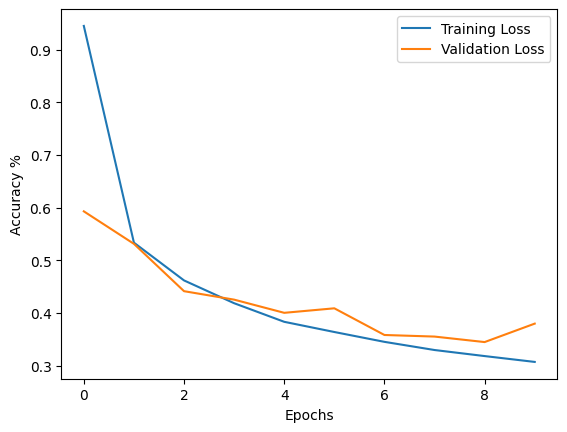

In [59]:
import matplotlib.pyplot as plt
plt.plot(range(epochs), loss_history, label="Training Loss")
plt.plot(range(epochs), val_history, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Accuracy %")
plt.legend()
plt.show()

In [60]:
### Evaluation of LeNet5 model
with torch.no_grad():
    model_LeNet5.eval()
    accuracy = 0.0
    for val_inputs, val_labels in test_dataloader:
        val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
        val_outputs = model_LeNet5(val_inputs)
        val_loss += criterian(val_outputs, val_labels).item()
        _, predicted = torch.max(val_outputs.data, 1)
        accuracy += (predicted == val_labels).sum().item()
    print(f"Test Accuracy of LeNet5 model: {accuracy/len(test_data):.4f}")
    

Test Accuracy of LeNet5 model: 0.8603


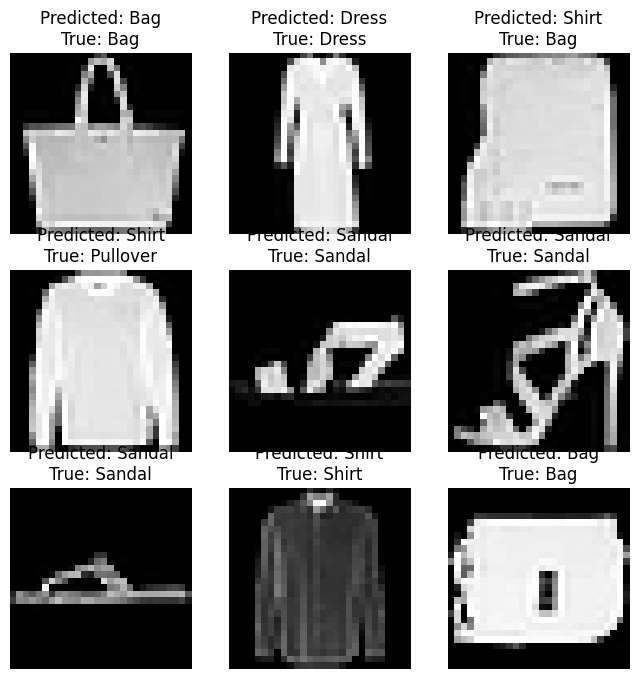

In [63]:
### Prediction of dansom 9 samples from test dataset
import matplotlib.pyplot as plt
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols*rows + 1):
    sample_idx = torch.randint(len(test_data), size=(1,)).item()
    img, label = test_data[sample_idx]
    with torch.no_grad():
        model_LeNet5.to("cpu")
        model_LeNet5.eval()
        img = img.unsqueeze(0)  # Add batch dimension
        output = model_LeNet5(img)
        _, prediction = torch.max(output.data, 1)
    figure.add_subplot(rows, cols, i)
    plt.title(f"Predicted: {labels_map[prediction.item()]}\nTrue: {labels_map[label]}")
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### **Lightweight CNN**

In [64]:
### Standard Conv Layer
class StandardConvLayer(nn.Module):
    def __init__(self, in_channel, output_channel):
        super(StandardConvLayer, self).__init__()
        self.conv = nn.Conv2d(in_channel, output_channel, kernel_size=3, stride=1, padding=1)
    
    def forward(self, x):
        x = self.conv(x)
        return x
    
### Grouped Conv Layer

class GroupedConvLayer(nn.Module):
    def __init__(self, in_channel, output_channel, groups):
        super(GroupedConvLayer, self).__init__()
        self.conv = nn.Conv2d(in_channel, output_channel, kernel_size=3, stride=1, padding=1, groups=groups)
    
    def forward(self, x):
        x = self.conv(x)
        return x

### Separable Convolution layer example.
class SeparableConvLayer(nn.Module):
    def __init__(self, in_channel, output_channel):
        super(SeparableConvLayer, self).__init__()
        self.depthwise = nn.Conv2d(in_channel, in_channel, kernel_size=3, stride=1, padding=1, groups=in_channel)
        self.pointwise = nn.Conv2d(in_channel, output_channel, kernel_size=1, stride=1, padding=0)
    
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

In [69]:
### Example
std_conv_layer = StandardConvLayer(in_channel=32, output_channel=64)
group_conv_layer = GroupedConvLayer(in_channel=32, output_channel=64, groups=32) 
sep_conv_layer = SeparableConvLayer(in_channel=32, output_channel=64)
input_tensor = torch.randn(1, 32, 28, 28)  # Batch size of 1, 3 channels, 28x28 image
output_tensor_std = std_conv_layer(input_tensor)
output_tensor_group = group_conv_layer(input_tensor)
output_tensor_sep = sep_conv_layer(input_tensor)

print(f"Input shape: {input_tensor.shape}")
print(f"\nTensor shape of Standard Conv Layer: {output_tensor_std.shape}")
print(f"Number of params in Standard conv layer: {count_parameters(std_conv_layer)}")
print(f"\nTensor shape of Grouped Conv Layer: {output_tensor_group.shape}")
print(f"Number of params in Grouped conv layer: {count_parameters(group_conv_layer)}")
print(f"\nTensor shape after Separable Conv Layer: {output_tensor_sep.shape}")
print(f"Number of params in Separable conv layer: {count_parameters(sep_conv_layer)}")

Input shape: torch.Size([1, 32, 28, 28])

Tensor shape of Standard Conv Layer: torch.Size([1, 64, 28, 28])
Number of params in Standard conv layer: 18496

Tensor shape of Grouped Conv Layer: torch.Size([1, 64, 28, 28])
Number of params in Grouped conv layer: 640

Tensor shape after Separable Conv Layer: torch.Size([1, 64, 28, 28])
Number of params in Separable conv layer: 2432


In [70]:
### Building AlexNet SepCNN Model
class SeparableConvLayer(nn.Module):
    def __init__(self, in_channel, output_channel, kernel_size=3, stride=1, padding=1):
        super(SeparableConvLayer, self).__init__()
        self.depthwise = nn.Conv2d(in_channel, in_channel, kernel_size=kernel_size, stride=stride, padding=padding, groups=in_channel)
        self.pointwise = nn.Conv2d(in_channel, output_channel, kernel_size=1, stride=1, padding=0)
    
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

### LeNet-5 Architecture
class SepLeNet5(nn.Module):
    def __init__(self, in_channel, num_classes):
        super(SepLeNet5, self).__init__()
        self.conv1 = SeparableConvLayer(in_channel, 6, kernel_size=5, stride=1, padding=0)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = SeparableConvLayer(6, 16, kernel_size=5, stride=1, padding=0)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(-1, 16 * 4 * 4)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [71]:
model_sep_Lenet5 = SepLeNet5(in_channel=1, num_classes=10)
print(model_sep_Lenet5)
num_params_sep_Lenet = count_parameters(model_sep_Lenet5)
print(f"Number of parameters in SepLeNet-5: {num_params_sep_Lenet}")

SepLeNet5(
  (conv1): SeparableConvLayer(
    (depthwise): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1))
    (pointwise): Conv2d(1, 6, kernel_size=(1, 1), stride=(1, 1))
  )
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): SeparableConvLayer(
    (depthwise): Conv2d(6, 6, kernel_size=(5, 5), stride=(1, 1), groups=6)
    (pointwise): Conv2d(6, 16, kernel_size=(1, 1), stride=(1, 1))
  )
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu): ReLU()
)
Number of parameters in SepLeNet-5: 42160


### **Custom CNN Models**

In [72]:
### Standard Conv Layer
class StandardConvLayer(nn.Module):
    def __init__(self, in_channel, output_channel):
        super(StandardConvLayer, self).__init__()
        self.conv = nn.Conv2d(in_channel, output_channel, kernel_size=3, stride=1, padding=1)
    
    def forward(self, x):
        x = self.conv(x)
        return x
class myStdCNN(nn.Module):
    def __init__(self, in_channel, num_classes):
        super(myStdCNN, self).__init__()
        self.conv1 = StandardConvLayer(in_channel, 32)
        self.conv2 = StandardConvLayer(32, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv3 = StandardConvLayer(64, 128)
        self.conv4 = StandardConvLayer(128, 256)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(256 * 7 * 7, 50)
        self.fc2 = nn.Linear(50, num_classes)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv2(self.conv1(x)))
        x = self.pool1(x)
        x = self.relu(self.conv4(self.conv3(x)))
        x = self.pool2(x)
        x = x.view(-1, 256 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [73]:
my_custom_model = myStdCNN(in_channel=1, num_classes=10)
print(my_custom_model)
num_params_my_custom_model = count_parameters(my_custom_model)
print(f"Number of parameters in myStdCNN: {num_params_my_custom_model}")

myStdCNN(
  (conv1): StandardConvLayer(
    (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (conv2): StandardConvLayer(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): StandardConvLayer(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (conv4): StandardConvLayer(
    (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=12544, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
  (relu): ReLU()
)
Number of parameters in myStdCNN: 1015600


In [74]:
### Separable Convolution layer example.
class SeparableConvLayer(nn.Module):
    def __init__(self, in_channel, output_channel):
        super(SeparableConvLayer, self).__init__()
        self.depthwise = nn.Conv2d(in_channel, in_channel, kernel_size=3, stride=1, padding=1)
        self.pointwise = nn.Conv2d(in_channel, output_channel, kernel_size=1, stride=1, padding=0)
    
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x
    
class myDWSCNN(nn.Module):
    def __init__(self, in_channel, num_classes):
        super(myDWSCNN, self).__init__()
        self.conv1 = SeparableConvLayer(in_channel, 32)
        self.conv2 = SeparableConvLayer(32, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv3 = SeparableConvLayer(64, 128)
        self.conv4 = SeparableConvLayer(128, 256)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(256 * 7 * 7, 50)
        self.fc2 = nn.Linear(50, num_classes)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv2(self.conv1(x)))
        x = self.pool1(x)
        x = self.relu(self.conv4(self.conv3(x)))
        x = self.pool2(x)
        x = x.view(-1, 256 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [75]:
my_custom_model_DWSCNN = myDWSCNN(in_channel=1, num_classes=10)
print(my_custom_model_DWSCNN)
num_params_my_custom_model = count_parameters(my_custom_model_DWSCNN)
print(f"Number of parameters in myStdCNN: {num_params_my_custom_model}")

myDWSCNN(
  (conv1): SeparableConvLayer(
    (depthwise): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (pointwise): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1))
  )
  (conv2): SeparableConvLayer(
    (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (pointwise): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): SeparableConvLayer(
    (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (conv4): SeparableConvLayer(
    (depthwise): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (pointwise): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1))
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=12544, out_features=50, bias=True)
  (fc2): Line

In [76]:
### Building AlexNet CNN Model
class Alex_Net(nn.Module):
    def __init__(self, in_channel, output_channel):
        super(Alex_Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channel, 96, kernel_size=11, stride=4, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.fc1 = nn.Linear(256*6*6, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.output = nn.Linear(4096, output_channel)
    
    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = self.pool3(x)
        x = x.view(-1, 256*6*6)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.output(x)
        return x


In [77]:
model_AlexNet = Alex_Net(in_channel=1, output_channel=10)
print(model_AlexNet)

Alex_Net(
  (conv1): Conv2d(1, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=9216, out_features=4096, bias=True)
  (fc2): Linear(in_features=4096, out_features=4096, bias=True)
  (output): Linear(in_features=4096, out_features=10, bias=True)
)


In [78]:
num_params = count_parameters(model_AlexNet)
print(f"Number of parameters in Alex_Net: {num_params}")

Number of parameters in Alex_Net: 56971594
